In [1]:
# Cell 1 — Setup
"""
07_temperature.ipynb
====================
Temperature dependence analysis — key advantage of physics-informed approach.
"""

import sys
sys.path.insert(0, "../src")

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tgnn_solv.inference import load_model, temperature_scan
from tgnn_solv.eval_temperature import (
    temperature_coverage,
    vant_hoff_check,
    evaluate_multi_T_pairs,
)
from tgnn_solv.data import PROCESSED_DIR

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

model, cfg = load_model("../checkpoints/tgnn_solv_trained.pt", DEVICE)

Model loaded from ../checkpoints/tgnn_solv_trained.pt
  test_mae: 1.9185993671417236
  test_rmse: 2.623523712158203
  test_r2: 0.03923875093460083
  n_train: 104625
  n_test: 7787


In [2]:
# Cell 2 — Temperature coverage in dataset
unified = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")
all_data = pd.concat([unified, val_df, test_df], ignore_index=True)

coverage = temperature_coverage(all_data)

  Records from multi-T pairs:     101,383

  Temperature distribution:
    [200, 270) K:    376 
    [270, 290) K: 22,507 ██████████████████████
    [290, 300) K: 21,821 █████████████████████
    [300, 310) K: 22,352 █████████████████████
    [310, 330) K: 30,797 ██████████████████████████████
    [330, 360) K:  3,736 ███
    [360, 400) K:    166 
    [400, 500) K:      8 


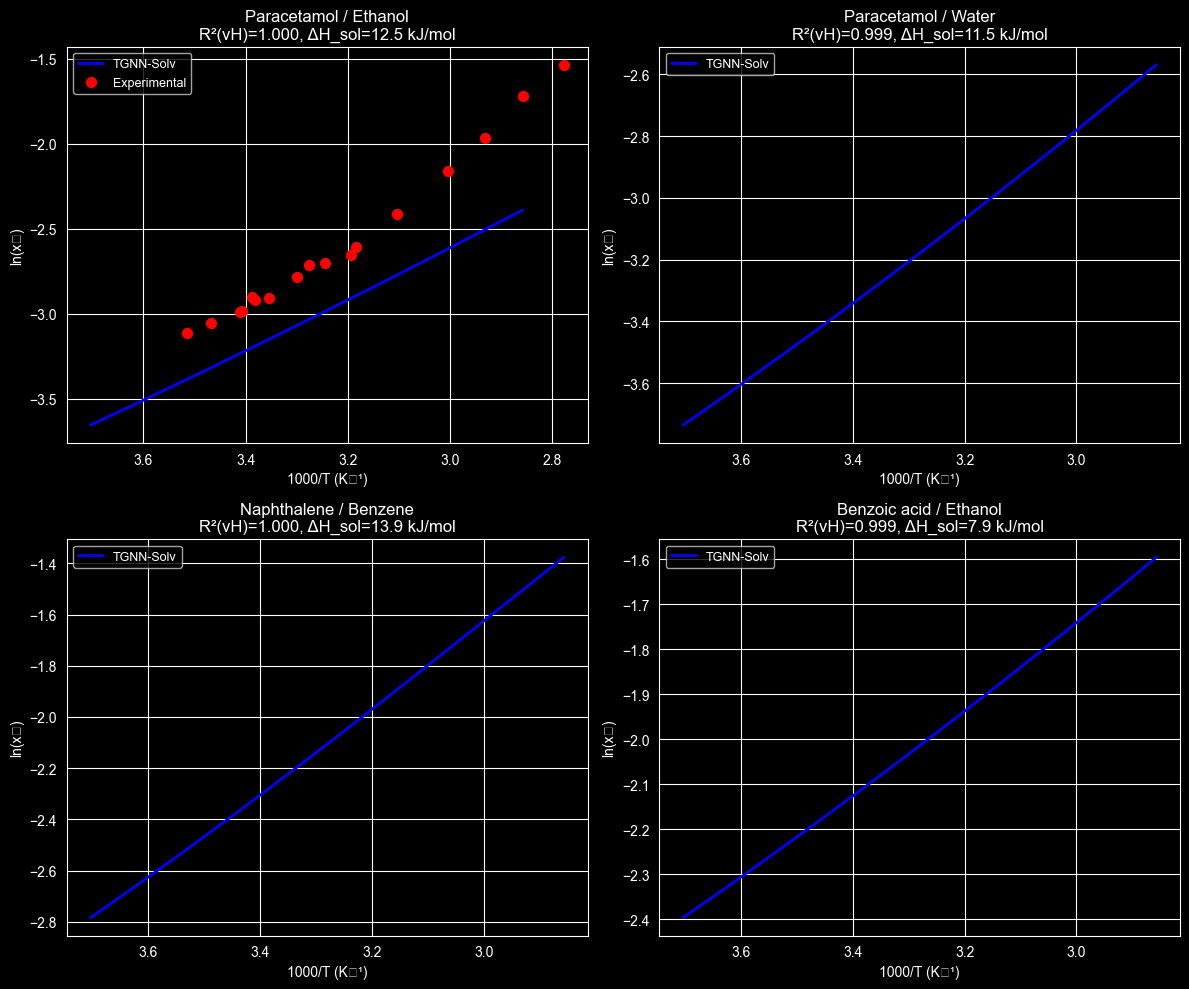

In [3]:
# Cell 3 — van't Hoff plots for representative systems

systems = [
    ("CC(=O)Nc1ccc(O)cc1", "CCO", "Paracetamol / Ethanol"),
    ("CC(=O)Nc1ccc(O)cc1", "O", "Paracetamol / Water"),
    ("c1ccc2ccccc2c1", "c1ccccc1", "Naphthalene / Benzene"),
    ("OC(=O)c1ccccc1", "CCO", "Benzoic acid / Ethanol"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (sol, slv, title) in zip(axes.flat, systems):
    vH = vant_hoff_check(
        model, sol, slv,
        T_range=(270, 350), n_points=30,
        experimental=all_data,
    )

    scan = vH["scan"]
    inv_T = 1000.0 / scan["T"].values
    ln_x2 = scan["ln_x2"].values

    # Predicted curve
    ax.plot(inv_T, ln_x2, "b-", lw=2, label="TGNN-Solv")

    # Experimental points (if available)
    if "exp_T" in vH:
        exp_inv_T = 1000.0 / vH["exp_T"]
        ax.scatter(exp_inv_T, vH["exp_ln_x2"],
                   c="red", s=50, zorder=5, label="Experimental")

    ax.set_xlabel("1000/T (K⁻¹)")
    ax.set_ylabel("ln(x₂)")
    ax.set_title(f"{title}\n"
                 f"R²(vH)={vH['vH_r2']:.3f}, "
                 f"ΔH_sol={vH['dH_sol_effective']/1000:.1f} kJ/mol")
    ax.legend(fontsize=9)
    ax.invert_xaxis()

plt.tight_layout()
plt.savefig("../checkpoints/vant_hoff_plots.png", dpi=150)
plt.show()

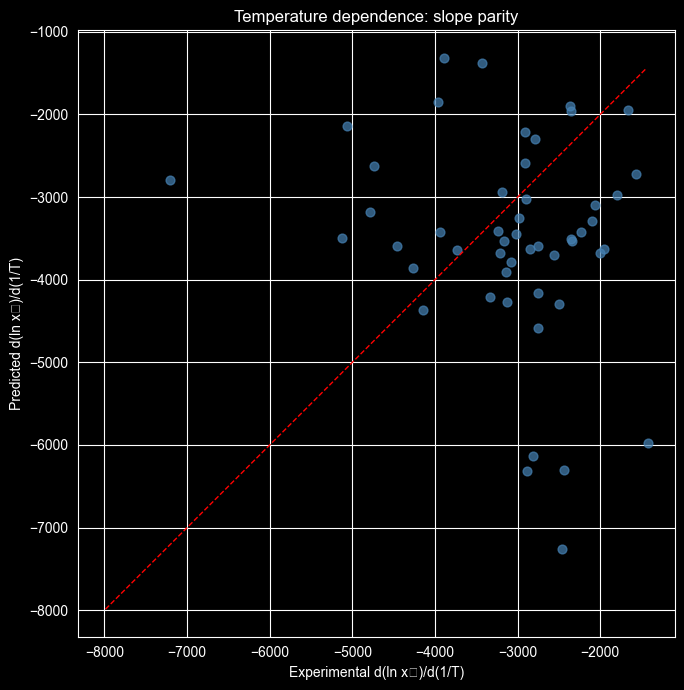

In [4]:
# Cell 4 — Multi-T pair evaluation

multi_T_results = evaluate_multi_T_pairs(
    model, all_data, min_T_points=3, max_pairs=50,
)

if len(multi_T_results) > 0:
    print("\nTop 10 pairs by MAE:")
    print(multi_T_results.sort_values("mae").head(10).to_string(
        index=False, float_format="{:.3f}".format
    ))

    # Slope comparison plot
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(
        multi_T_results["exp_slope"],
        multi_T_results["pred_slope"],
        s=40, alpha=0.7, c="steelblue",
    )
    lims = [
        min(multi_T_results["exp_slope"].min(),
            multi_T_results["pred_slope"].min()) * 1.1,
        max(multi_T_results["exp_slope"].max(),
            multi_T_results["pred_slope"].max()) * 1.1,
    ]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("Experimental d(ln x₂)/d(1/T)")
    ax.set_ylabel("Predicted d(ln x₂)/d(1/T)")
    ax.set_title("Temperature dependence: slope parity")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig("../checkpoints/T_slope_parity.png", dpi=150)
    plt.show()

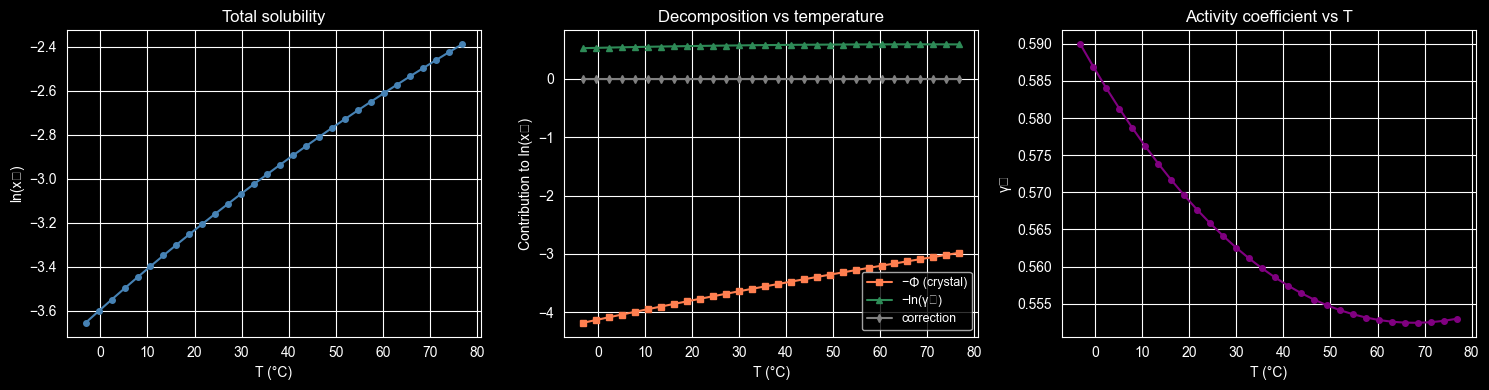

In [8]:
# Cell 5 — Decomposition: why does solubility increase with T?

from tgnn_solv.inference import predict_solubility

sol_smi = "CC(=O)Nc1ccc(O)cc1"  # paracetamol
slv_smi = "CCO"                  # ethanol

# Collect all data in one pass
T_values = np.linspace(270, 350, 30)
records = []
for T_val in T_values:
    r = predict_solubility(model, sol_smi, slv_smi, float(T_val))
    records.append(r)

scan_df = pd.DataFrame(records)
T_celsius = scan_df["T"].values - 273.15

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total solubility
ax = axes[0]
ax.plot(T_celsius, scan_df["ln_x2"], "o-", color="steelblue", ms=4)
ax.set_xlabel("T (°C)")
ax.set_ylabel("ln(x₂)")
ax.set_title("Total solubility")

# Decomposition: ideal + non-ideal + correction
ax = axes[1]
Phi_vals = -scan_df["Phi"].values
lng_vals = -scan_df["ln_gamma_2"].values
corr_vals = scan_df["correction"].values

ax.plot(T_celsius, Phi_vals, "s-", label="−Φ (crystal)", color="coral", ms=4)
ax.plot(T_celsius, lng_vals, "^-", label="−ln(γ₂)", color="seagreen", ms=4)
ax.plot(T_celsius, corr_vals, "d-", label="correction", color="gray", ms=4)
ax.set_xlabel("T (°C)")
ax.set_ylabel("Contribution to ln(x₂)")
ax.set_title("Decomposition vs temperature")
ax.legend(fontsize=9)

# γ₂ vs T
ax = axes[2]
ax.plot(T_celsius, scan_df["gamma_2"], "o-", color="purple", ms=4)
ax.set_xlabel("T (°C)")
ax.set_ylabel("γ₂")
ax.set_title("Activity coefficient vs T")

plt.tight_layout()
plt.savefig("../checkpoints/T_decomposition.png", dpi=150)
plt.show()